# IND320 - Part 2: Data sources

This notebook builds on the reservoir analysis from Part 1. The NVE section reads observations directly from the API. The electricity transfer and database sections are still in progress.

- [GitHub repository](https://github.com/Sipan2/IND320-Sipan2)
- [Streamlit app](https://ind320-sipan2.streamlit.app/)
- [NVE API documentation](https://biapi.nve.no/magasinstatistikk/swagger/index.html)

The repository and app links currently refer to Part 1. This Part 2 draft has not been published.

## 1. Reservoir data from NVE

The API replaces the local CSV file used in Part 1. Because the source is updated, later runs may return additional observations.

In [1]:
import json
from datetime import datetime, timezone
from urllib.request import urlopen
import pandas as pd

# NVE provides public reservoir observations as JSON.
url = "https://biapi.nve.no/magasinstatistikk/api/Magasinstatistikk/HentOffentligData"
with urlopen(url, timeout=60) as response:
    observations = json.load(response)

retrieved_at = datetime.now(timezone.utc)
print("Retrieved at (UTC):", retrieved_at.isoformat(timespec="seconds"))
reservoirs = pd.DataFrame(observations)
reservoirs.head()

Retrieved at (UTC): 2026-10-07T15:58:08+00:00


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 2. Check dates, areas and measurements

Each series is identified by both its area type and area number. The checks below show the date range, the number of observations per area and any duplicate records. The observation date is kept separate from the publication date.

In [2]:
# Check dates and use both area fields to identify each series.
reservoirs["dato_Id"] = pd.to_datetime(reservoirs["dato_Id"])
reservoirs = reservoirs.sort_values(["omrType", "omrnr", "dato_Id"])
print("Rows:", len(reservoirs))
print("Dates:", reservoirs["dato_Id"].min().date(), "to", reservoirs["dato_Id"].max().date())
print("Duplicate area/date rows:", reservoirs.duplicated(["omrType", "omrnr", "dato_Id"]).sum())
reservoirs.groupby(["omrType", "omrnr"]).size().rename("observations").to_frame()

Rows: 14913
Dates: 1995-01-08 to 2026-10-04
Duplicate area/date rows: 0


observations
omrType omrnr              
EL      1              1657
        2              1657
        3              1657
        4              1657
        5              1657
NO      0              1657
VASS    1              1657
        2              1657
        3              1657

### English column names and national series

NO 0 is the national series. We keep the observation date on the horizontal axis and do not use the next publication date as a measurement date.

In [3]:
# Rename the API fields and select the national observations.
column_names = {
    "dato_Id": "date", "omrType": "area_type", "omrnr": "area_number",
    "iso_aar": "iso_year", "iso_uke": "iso_week",
    "fyllingsgrad": "filling_ratio", "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_filling_ratio",
    "endring_fyllingsgrad": "weekly_filling_ratio_change",
}
data = reservoirs.rename(columns=column_names)
national = data.loc[(data.area_type == "NO") & (data.area_number == 0)].set_index("date")
measurements = ["filling_ratio", "capacity_twh", "stored_energy_twh",
                "previous_week_filling_ratio", "weekly_filling_ratio_change"]
national[measurements].head()

,filling_ratio,capacity_twh,stored_energy_twh,previous_week_filling_ratio,weekly_filling_ratio_change
date,,,,,
1995-01-08,0.607988,87.43758,53.161003,0.752631,-0.144643
1995-01-15,0.582088,87.43758,50.896374,0.607988,-0.025900
1995-01-22,0.562121,87.43758,49.150486,0.582088,-0.019967
1995-01-29,0.534222,87.43758,46.711033,0.562121,-0.027899
1995-02-05,0.506221,87.43758,44.262720,0.534222,-0.028001


### Missing values and week numbers

These checks help distinguish missing measurements from gaps in a series. The ISO year and week are compared with the observation date, rather than assuming the calendar year is always the ISO year. The next publication date is metadata and is not used to place observations on the time axis.

In [4]:
# Check all areas before choosing a series for plotting.
quality = data[measurements].agg(["count", "min", "max"]).T
quality["missing"] = data[measurements].isna().sum()
display(quality)

# Compare the supplied ISO fields with the actual observation dates.
iso_dates = data["date"].dt.isocalendar()
week_mismatch = (data["iso_year"] != iso_dates["year"]) | (data["iso_week"] != iso_dates["week"])
print("Rows with different ISO year/week:", int(week_mismatch.sum()))

# Show gaps without filling or inventing observations.
gaps = data.groupby(["area_type", "area_number"])["date"].diff().dt.days
print("Intervals other than seven days:", int((gaps.notna() & gaps.ne(7)).sum()))
print("Publication dates beginning with year 0001:",
      int(data["next_publication_date"].astype(str).str.startswith("0001").sum()))

,count,min,max,missing
filling_ratio,14913.0,0.051653,1.020072,0
capacity_twh,14913.0,6.003264,87.437580,0
stored_energy_twh,14913.0,0.310089,84.518060,0
previous_week_filling_ratio,14913.0,0.051653,1.020037,0
weekly_filling_ratio_change,14913.0,-0.242484,0.345632,0


Rows with different ISO year/week: 0
Intervals other than seven days: 0
Publication dates beginning with year 0001: 11322


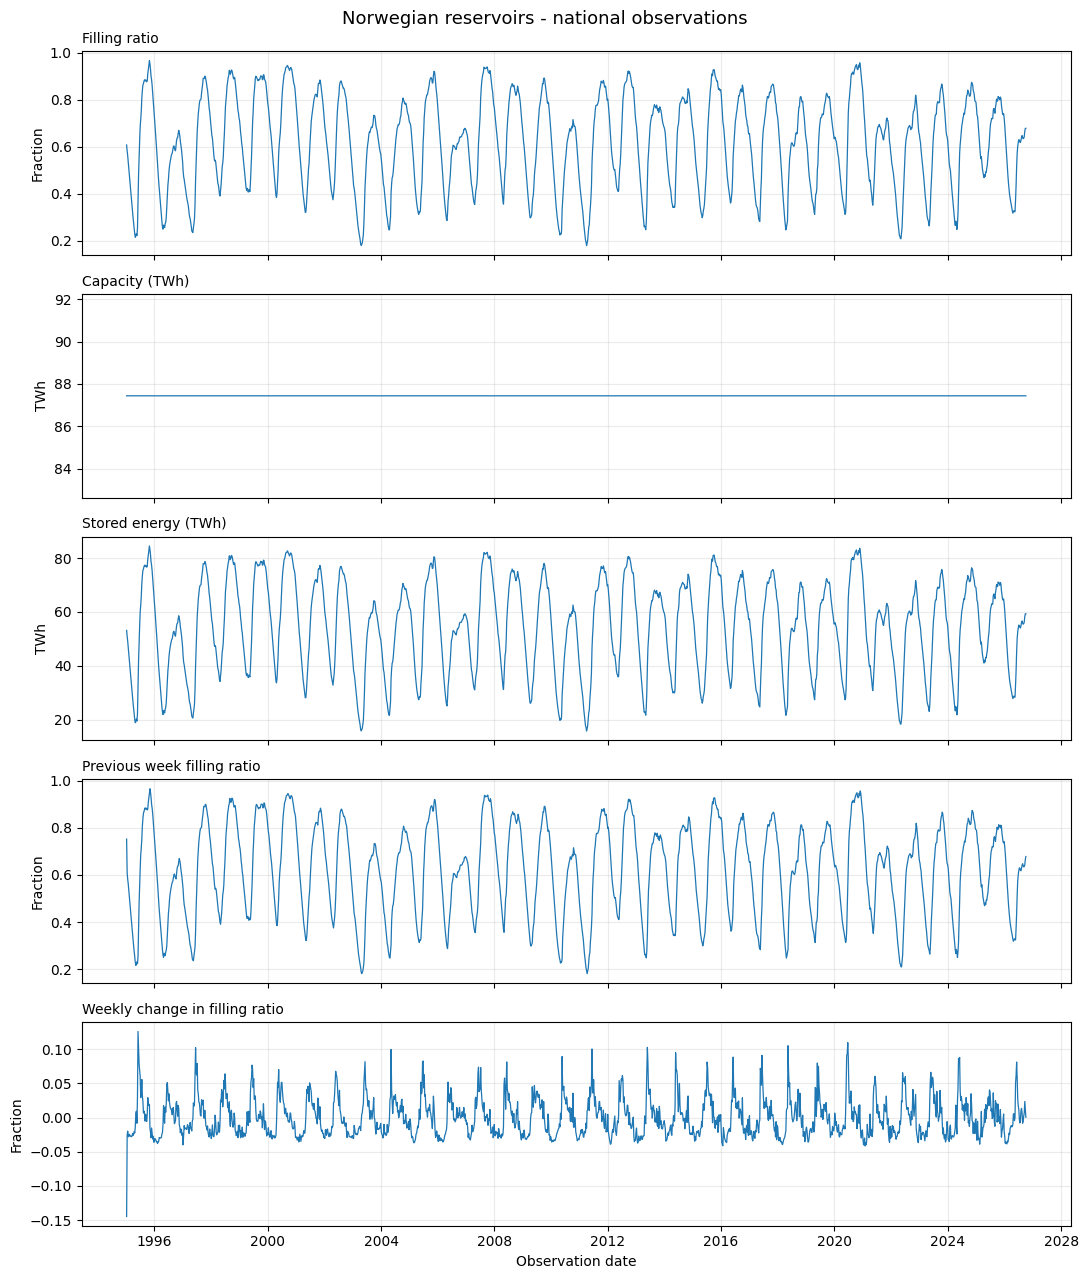

In [5]:
import matplotlib.pyplot as plt

# Separate axes preserve the original units of each measurement.
labels = ["Filling ratio", "Capacity (TWh)", "Stored energy (TWh)",
          "Previous week filling ratio", "Weekly change in filling ratio"]
fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True)
for ax, column, label in zip(axes, measurements, labels):
    ax.plot(national.index, national[column], linewidth=0.9)
    ax.set_title(label, loc="left", fontsize=10)
    ax.set_ylabel("TWh" if column.endswith("twh") else "Fraction")
    ax.grid(alpha=0.25)
fig.suptitle("Norwegian reservoirs - national observations", fontsize=13)
axes[-1].set_xlabel("Observation date")
fig.tight_layout()
plt.show()

### Comparing changes on one scale

Min-max scaling maps each changing series to 0-1. Constant series have no range, so they are left out of this comparison and listed below. Their original values are still shown in the separate plots.

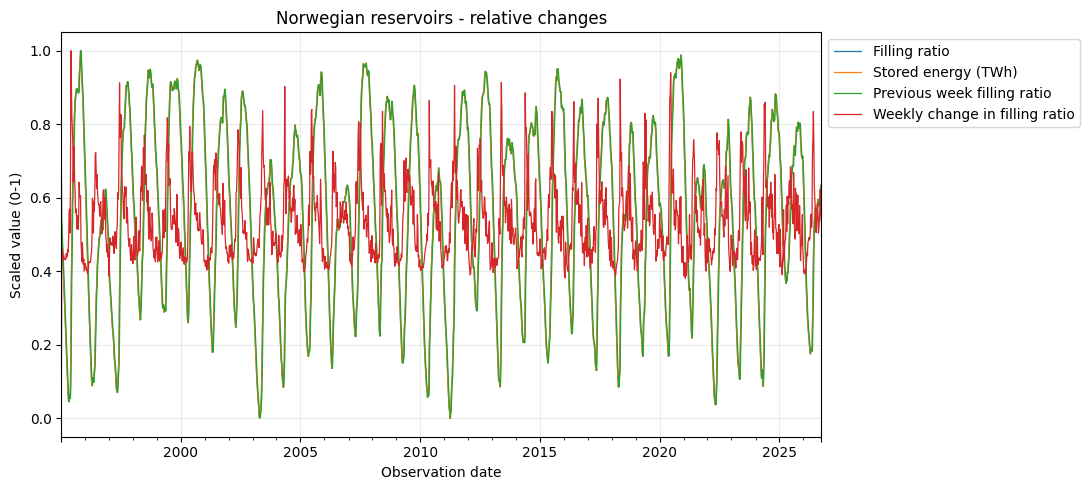

Constant measurements omitted: ['capacity_twh']


In [6]:
# Avoid division by zero for measurements that stay constant.
values = national[measurements]
span = values.max() - values.min()
changing = span[span > 0].index
constant = span[span == 0].index.tolist()
scaled = (values[changing] - values[changing].min()) / span[changing]
ax = scaled.rename(columns=dict(zip(measurements, labels))).plot(figsize=(11, 5), linewidth=0.9)
ax.set_title("Norwegian reservoirs - relative changes")
ax.set_xlabel("Observation date")
ax.set_ylabel("Scaled value (0-1)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print("Constant measurements omitted:", constant)

The scaled lines can overlap, so this figure is best read alongside the separate plots. Scaling removes the original units: a value of 1 means the largest observed value for that series, not a full reservoir. Constant capacity remains visible in the separate plot.

## 3. Electricity transfers from ENTSO-E

Retrieve two years of cross-border transfers. The API token must stay outside the notebook and GitHub.

## 4. Check Spark and Cassandra locally

The local setup follows the course book: Python 3.12, Java 17, PySpark 3.5.1 and the Cassandra connector 3.5.1. Cassandra runs in Docker, with its database port available only on this computer.

Before retrieving the ENTSO-E data, I use 12 national NVE observations to test the connection. The script creates a small test table, writes the observations through Spark, reads them back and compares every value. This checks the setup; it does not replace the required electricity transfer analysis.

Start Docker Desktop and run `docker compose up -d` from the Part 2 folder before running the next cell. The first start can take a few minutes. The implementation is in `test_spark_cassandra.py`, alongside this notebook.

In [7]:
# Find the project helpers when running from the notebooks folder.
from pathlib import Path
import sys
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from test_spark_cassandra import main as check_local_database
check_local_database()

:: loading settings :: url = jar:file:/Users/sipan/Documents/IND320/part2/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /Users/sipan/Documents/IND320/part2/project/.ivy2/cache
The jars for the packages stored in: /Users/sipan/Documents/IND320/part2/project/.ivy2/jars
com.datastax.spark#spark-cassandra-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-39f59454-5a18-44a1-9257-4aeb0e4ba3f8;1.0
	confs: [default]


	found com.datastax.spark#spark-cassandra-connector_2.12;3.5.1 in central
	found com.datastax.spark#spark-cassandra-connector-driver_2.12;3.5.1 in central


	found org.scala-lang.modules#scala-collection-compat_2.12;2.11.0 in central


	found org.apache.cassandra#java-driver-core-shaded;4.18.1 in central
	found com.datastax.oss#native-protocol;1.5.1 in central


...

	[SUCCESSFUL ] io.dropwizard.metrics#metrics-core;4.1.18!metrics-core.jar(bundle) (76ms)
downloading https://repo1.maven.org/maven2/org/hdrhistogram/HdrHistogram/2.1.12/HdrHistogram-2.1.12.jar ...
	[SUCCESSFUL ] org.hdrhistogram#HdrHistogram;2.1.12!HdrHistogram.jar(bundle) (141ms)
downloading https://repo1.maven.org/maven2/org/reactivestreams/reactive-streams/1.0.3/reactive-streams-1.0.3.jar ...
	[SUCCESSFUL ] org.reactivestreams#reactive-streams;1.0.3!reactive-streams.jar (49ms)


downloading https://repo1.maven.org/maven2/org/apache/cassandra/java-driver-query-builder/4.18.1/java-driver-query-builder-4.18.1.jar ...
	[SUCCESSFUL ] org.apache.cassandra#java-driver-query-builder;4.18.1!java-driver-query-builder.jar(bundle) (81ms)
:: resolution report :: resolve 7811ms :: artifacts dl 3511ms
	:: modules in use:
	com.datastax.oss#java-driver-shaded-guava;25.1-jre-graal-sub-1 from central in [default]
	com.datastax.oss#native-protocol;1.5.1 from central in [default]
	com.datastax.spark#spark-cassandra-connector-driver_2.12;3.5.1 from central in [default]
	com.datastax.spark#spark-cassandra-connector_2.12;3.5.1 from central in [default]
	com.thoughtworks.paranamer#paranamer;2.8 from central in [default]
	com.typesafe#config;1.4.1 from central in [default]
	io.dropwizard.metrics#metrics-core;4.1.18 from central in [default]
	org.apache.cassandra#java-driver-core-shaded;4.18.1 from central in [default]
	org.apache.cassandra#java-driver-mapper-runtime;4.18.1 from central

	16 artifacts copied, 0 already retrieved (17388kB/143ms)
26/10/07 17:58:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


+----------+-------------+
|date      |filling_ratio|
+----------+-------------+
|2026-07-19|0.6205158    |
|2026-07-26|0.6182537    |
|2026-08-02|0.6281369    |
|2026-08-09|0.64144284   |
|2026-08-16|0.6478905    |
|2026-08-23|0.6395198    |
|2026-08-30|0.63438076   |
|2026-09-06|0.6362067    |
|2026-09-13|0.64290357   |
|2026-09-20|0.6663861    |
|2026-09-27|0.67848873   |
|2026-10-04|0.67885876   |
+----------+-------------+

PASS: 12 NVE observations written and read back through Spark and Cassandra.


## 5. Plot imports and exports

Use annual energy totals for the pie chart. Account for the duration of each interval when converting power to energy.

## 6. Prepare data for MongoDB and Streamlit

## 7. AI usage and work log

Write this section after completing the work so it describes what actually happened.